# NES-RE: Neural Ensemble Search with Regularized Evolution

In this notebook, we demonstrate **NES-RE** — Neural Ensemble Search with Regularized Evolution (Zaidi et al., NeurIPS 2021).

Unlike NES-RS which samples architectures randomly, NES-RE **evolves** a population of architectures:

1. **Initialise** a population of `P` randomly sampled, trained architectures.
2. At each iteration, apply **`ForwardSelect`** to the population to identify the `m` most
   ensemble-compatible candidates, then sample one as the **parent**.
3. **Mutate** the parent (change one architectural decision) to produce a **child**, train it,
   add it to the population, and remove the **oldest** member (regularized evolution).
4. Repeat until the total budget `K` models have been trained.
5. Apply `ForwardSelect` over the full history to pick the final `M`-member ensemble.

The key advantage over NES-RS: the evolving population is **biased towards architectures that
work well together**, not just individually.

In [1]:
# 🛠 Setup: Import library from parent folder
# This allows you to run the notebook without installing the package via pip
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# Bensemble imports
from bensemble import EvolutionarySearcher, SearchSpace
from bensemble.search import regression_mse_criterion

# Set seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

## 1. Generate Synthetic Data

We reuse the same synthetic dataset as `mc_dropout_demo`: $y = x^3 + \varepsilon$, $\varepsilon \sim \mathcal{N}(0, 1)$.

Notice that we train on range `[-2, 2]`, but later we will test on `[-4, 4]` to see how the ensemble behaves on out-of-distribution data.

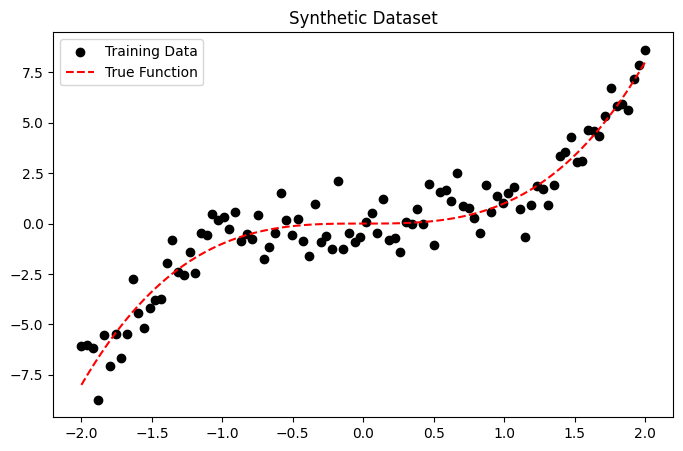

In [2]:
def true_function(x):
    return x ** 3

# Generate Training Data
x_train = torch.linspace(-2, 2, 100).reshape(-1, 1)
y_train = true_function(x_train) + torch.randn_like(x_train)  # Add noise

# Visualisation
plt.figure(figsize=(8, 5))
plt.scatter(x_train, y_train, c='k', label='Training Data')
plt.plot(x_train, true_function(x_train), 'r--', label='True Function')
plt.legend()
plt.title("Synthetic Dataset")
plt.show()

## 2. Define the Search Space

Same `ToySearchSpace` as in `nes_rs_demo`, with **two** architectural axes:

| Axis | Choices |
|---|---|
| Hidden width | 16, 32, 64, 128 |
| Depth (hidden layers) | 1, 2, 3 |

This gives 4 × 3 = 12 distinct architectures. `mutate` flips one axis at a time, so the
evolutionary search explores the space by taking single steps in either direction.

In [3]:
class ToySearchSpace(SearchSpace):
    WIDTHS  = [16, 32, 64, 128]
    DEPTHS  = [1, 2, 3]          # number of hidden layers

    def sample(self) -> dict:
        return {
            "hidden": self.WIDTHS[torch.randint(len(self.WIDTHS), ()).item()],
            "depth":  self.DEPTHS[torch.randint(len(self.DEPTHS), ()).item()],
        }

    def mutate(self, config: dict) -> dict:
        # Flip one of the two axes at random
        new = dict(config)
        if torch.rand(()).item() < 0.5:
            new["hidden"] = random.choice([w for w in self.WIDTHS if w != config["hidden"]])
        else:
            new["depth"]  = random.choice([d for d in self.DEPTHS if d != config["depth"]])
        return new

    def build(self, config: dict) -> nn.Module:
        layers: list[nn.Module] = []
        in_features = 1
        for _ in range(config["depth"]):
            layers += [nn.Linear(in_features, config["hidden"]), nn.ReLU()]
            in_features = config["hidden"]
        layers.append(nn.Linear(in_features, 1))
        return nn.Sequential(*layers)

import random
print(ToySearchSpace().build(ToySearchSpace().sample()))

Sequential(
  (0): Linear(in_features=1, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=16, bias=True)
  (3): ReLU()
  (4): Linear(in_features=16, out_features=1, bias=True)
)


## 3. Setup Objectives

Same training function as `nes_rs_demo`.

`train_fn` receives a freshly built model and trains it in-place using MSE loss.

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

def train_fn(model: nn.Module) -> None:
    """Train model in-place for 300 epochs with MSE loss.

    Intentionally under-trained: models of different architectures fit x³
    differently at 300 epochs, preserving ensemble diversity. Fully converged
    models (1000+ epochs) collapse to the same solution and kill the std band.
    """
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    loss_fn = nn.MSELoss()
    xb = x_train.to(device)
    yb = y_train.to(device)
    model.train()
    for _ in range(300):
        optimizer.zero_grad()
        loss_fn(model(xb), yb).backward()
        optimizer.step()

val_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32)

Using device: cuda


## 4. Run NES-RE

`EvolutionarySearcher` trains a total of `pool_size=20` models:

| Parameter | Value | Meaning |
|---|---|---|
| `pool_size` | 20 | Total computational budget K (models trained) |
| `ensemble_size` | 5 | Final ensemble size M |
| `population_size` | 5 | Evolving population P |
| `num_parent_candidates` | 3 | Parent candidates selected per iteration m |

**Evolution steps after initialisation:** `pool_size − population_size = 15`

At each step the parent is chosen by applying `ForwardSelect` to the current population —
so parent selection is **ensemble-aware**, not just based on individual validation loss.

In [5]:
searcher = EvolutionarySearcher(
    space=ToySearchSpace(),
    pool_size=20,
    ensemble_size=5,
    population_size=5,
    num_parent_candidates=3,
    train_fn=train_fn,
    device=device,
    criterion=regression_mse_criterion,
)

ensemble = searcher.search(val_loader)
print(f'Ensemble built — {ensemble.num_members} members')

Ensemble built — 5 members


## 5. Visualisation & Uncertainty

We predict on the wider range `[-4, 4]` to observe out-of-distribution behaviour.

- **Predictive mean** — average regression output across ensemble members.
- **Uncertainty band** — $\pm 2\sigma$ of per-member outputs (≈ 95 % interval).
- **True function** — $x^3$ (red dashed).

Notice how the uncertainty (blue area) expands where we have no training data.

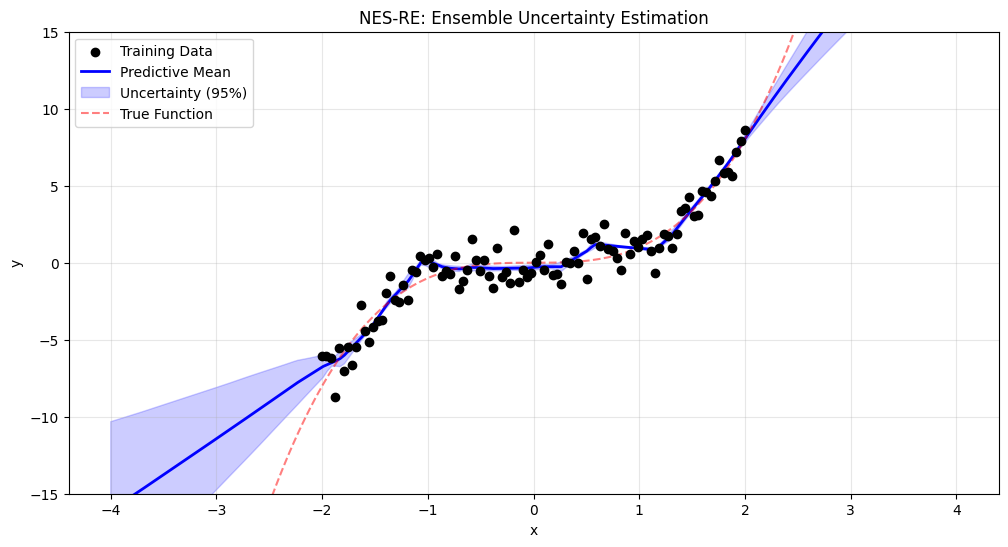

In [6]:
x_test = torch.linspace(-4, 4, 200).reshape(-1, 1)

with torch.no_grad():
    # predict_members returns (M, N, 1) — per-member regression outputs
    member_preds = ensemble.predict_members(x_test.to(device))  # (M, N, 1)
    member_preds = member_preds.squeeze(-1).cpu()               # (M, N)

mean = member_preds.mean(dim=0).numpy()
std  = member_preds.std(dim=0, unbiased=True).numpy()
x_np = x_test.flatten().numpy()

# --- Plotting ---
plt.figure(figsize=(12, 6))

# Training data
plt.scatter(x_train, y_train, c='black', zorder=5, label='Training Data')

# Mean prediction
plt.plot(x_np, mean, c='blue', linewidth=2, label='Predictive Mean')

# Uncertainty band (2σ ≈ 95%)
plt.fill_between(x_np, mean - 2 * std, mean + 2 * std,
                 color='blue', alpha=0.2, label='Uncertainty (95%)')

# True function
plt.plot(x_np, true_function(torch.tensor(x_np)).numpy(), 'r--', alpha=0.5, label='True Function')

plt.ylim(-15, 15)
plt.title('NES-RE: Ensemble Uncertainty Estimation')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Comparing Member Predictions

We can inspect each member's regression curve to visualise how architectural diversity
translates to prediction diversity — the mechanism behind NES-RE's better calibration.

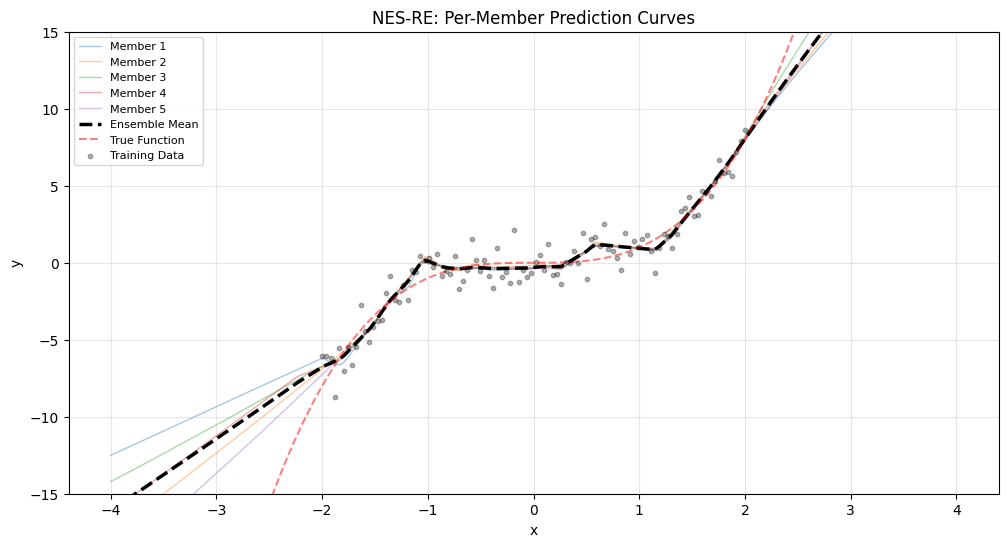

In [7]:
plt.figure(figsize=(12, 6))

# Individual member curves
for i, preds in enumerate(member_preds):   # member_preds: (M, N)
    plt.plot(x_np, preds.numpy(), alpha=0.4, linewidth=1, label=f'Member {i+1}')

# Ensemble mean on top
plt.plot(x_np, mean, c='black', linewidth=2.5, linestyle='--', label='Ensemble Mean')

# True function
plt.plot(x_np, true_function(torch.tensor(x_np)).numpy(), 'r--', alpha=0.5, label='True Function')

# Training data
plt.scatter(x_train, y_train, c='black', zorder=5, alpha=0.3, s=10, label='Training Data')

plt.ylim(-15, 15)
plt.title('NES-RE: Per-Member Prediction Curves')
plt.xlabel('x')
plt.ylabel('y')
plt.legend(loc='upper left', fontsize=8)
plt.grid(True, alpha=0.3)
plt.show()